In [1]:
# Import the system functions and download the data from the Think stats URL

from os.path import basename, exists

# This function is used to download all the required files used for NSFG

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkstats2.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkplot.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/nsfg.py")



In [3]:
#Exercise 5.1

download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/brfss.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/CDBRFS08.ASC.gz")

In [5]:
#import all the required functions need to be used for this excercise

import numpy as np
import thinkstats2
import thinkplot

In [7]:
#Importing demographic details from BRFSS

import brfss
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

df = brfss.ReadBrfss()
df.head(10)

,age,sex,wtyrago,finalwt,wtkg2,htm3
0,82.0,2,76.363636,185.870345,70.91,157.0
1,65.0,2,72.727273,126.603027,72.73,163.0
2,48.0,2,NaN,181.063210,NaN,165.0
3,61.0,1,73.636364,517.926275,73.64,170.0
4,26.0,1,88.636364,1252.624630,88.64,185.0
5,42.0,1,118.181818,415.161314,109.09,183.0
6,40.0,2,50.000000,422.810541,50.00,157.0
7,24.0,2,131.818182,1280.585980,122.73,178.0
8,37.0,1,87.727273,1245.060440,90.00,178.0
9,65.0,1,77.272727,382.738158,77.27,173.0


"In the BRFSS the distribution of heights is roughly normal with parameters µ = 182 cm and σ = 8.1 cm for men, and µ = 171 cm and σ = 7.3 cm for women."

In [9]:
#importing scipy.stats that contains objects that represent analytic distributions

import scipy.stats

mu = 182
sigma = 8.1
dist = scipy.stats.norm(loc=mu, scale=sigma)
type(dist)

scipy.stats._distn_infrastructure.rv_continuous_frozen

In [10]:
dist.mean(), dist.std()

(182.0, 8.1)

In [11]:
# Standard Deviation / Mean 

print("standard deviation/mean:",round(dist.cdf(mu - sigma)*100,2))

standard deviation/mean: 15.87


In [12]:
# Solution to see the spread for the heights between 5'4" (my height :-)) and 5'69" (others height) 

low = dist.cdf(165.5)  # 5'4"
high = dist.cdf(173.4)  # 5'69"
print("spread of height in lower range:",round(low*100,2)), 
print("spread of height in higher range:",round(high*100,2))
print("difference between distribution:",round((high - low)*100,2))

spread of height in lower range: 2.08
spread of height in higher range: 14.42
difference between distribution: 12.34


In [13]:
#Excecise 5.2 distribution of heights using pareto distribution method.

In [20]:
# For this excercise we will use scipy pareto function and that will let us know
# distribution around.

alpha = 1.9
xmin = 0.5  #meter
dist = scipy.stats.pareto(b=alpha, scale=xmin)
print("median distribution of data:",round(dist.median()*100,2))
print("mean distribution of data:",round(dist.mean()*100,2))

median distribution of data: 72.01
mean distribution of data: 105.56


In [22]:
#calculate the percentage of people shorter than above mean output

round(dist.cdf(dist.mean()*100),2)

1.0

In [24]:
#Out of 1 billion people, how many do we expect to be taller than 1 km?

# Solution

(1 - dist.cdf(1000)) * 1e9, dist.sf(1000) * 1e9


(534.6172999853849, 534.6172999955944)

In [26]:
# Solution

# One way to solve this is to search for a height that we expect one person 
# out of 1 billion to exceed.

dist.sf(100000) * 1e9

0.08473113193349588

In [28]:
#Excercise 6-1

# Downloading the household income file from census data using think stat
# and also python used to clean and format the file in csv format

download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/hinc.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/hinc06.csv")

In [30]:
def InterpolateSample(df, log_upper=6.0):
    """Makes a sample of log10 household income.

    Assumes that log10 income is uniform in each range.

    df: DataFrame with columns income and freq
    log_upper: log10 of the assumed upper bound for the highest range

    returns: NumPy array of log10 household income
    """
    # compute the log10 of the upper bound for each range
    df['log_upper'] = np.log10(df.income)

    # get the lower bounds by shifting the upper bound and filling in
    # the first element
    df['log_lower'] = df.log_upper.shift(1)
    df.loc[0, 'log_lower'] = 3.0

    # plug in a value for the unknown upper bound of the highest range
    df.loc[41, 'log_upper'] = log_upper
    
    # use the freq column to generate the right number of values in
    # each range
    arrays = []
    for _, row in df.iterrows():
        vals = np.linspace(row.log_lower, row.log_upper, int(row.freq))
        arrays.append(vals)

    # collect the arrays into a single sample
    log_sample = np.concatenate(arrays)
    return log_sample


In [32]:
import hinc
income_df = hinc.ReadData()

In [34]:
log_sample = InterpolateSample(income_df, log_upper=6.0)

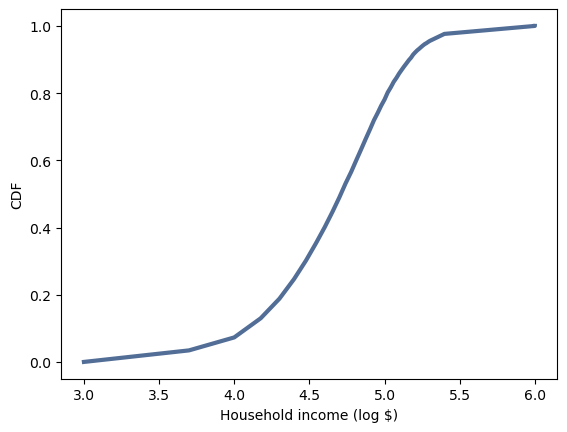

In [36]:
log_cdf = thinkstats2.Cdf(log_sample)
thinkplot.Cdf(log_cdf)
thinkplot.Config(xlabel='Household income (log $)',ylabel='CDF')

In [38]:
sample = np.power(10, log_sample)

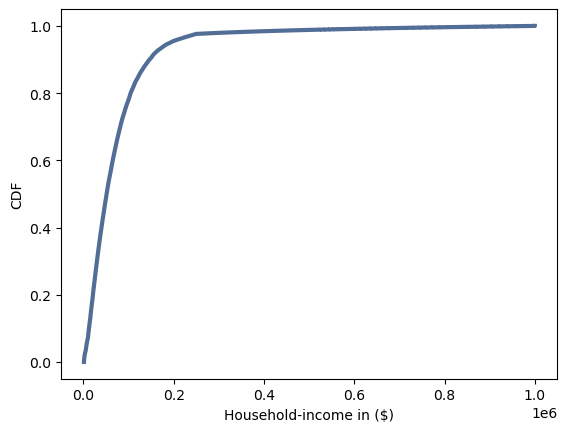

In [40]:
cdf = thinkstats2.Cdf(sample)
thinkplot.Cdf(cdf)
thinkplot.Config(xlabel='Household-income in ($)',ylabel='CDF')